# Train online run (M17 — paper seq / GRU / replay / free-nats / actor-on)

Closest Table B.1 + `train_ratio` 512 this 16 GiB box can run: **seq 64**,
**GRU 4096**, **replay 1e6**, paper **free_nats on both KL terms**, actor
**on from step 0**, prefill **2500**. Batch is **8** (16 × 64 pages the card).
AMP is **bf16** (fp32 smokes at 13.3 GiB; too tight live). Status **0/1M**.

Do not load M16 or any prior XL. First print must be
`config=m17_xl_paper.yaml  train_ratio=512` plus `seq=64 batch=8`
and `ac_warmup_env=0`. If it shows `m16` or `seq=32`, stop.

- **100k:** `recon_l1`, not last-200 gmean.
- **~180k / 500k:** last-200 **stone / table / pickaxe**. Gmean stays ~2 until stone moves.
- Unlock bars are **last-200 collect**, not the n=10 eval bag.

`ac_H` must stay off ~0.08. Kill if it sits near 0.10.
This is not a guaranteed 14.5. Do not launch this from the agent chat.


In [1]:
from __future__ import annotations

import gc
import json
import os
import sys
import time
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "src").is_dir():
    for candidate in (ROOT, *ROOT.parents):
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            ROOT = candidate
            break
os.chdir(ROOT)
src = str(ROOT / "src")
if src not in sys.path:
    sys.path.insert(0, src)
scripts = str(ROOT / "scripts")
if scripts not in sys.path:
    sys.path.insert(0, scripts)

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from torch.utils.tensorboard import SummaryWriter

from training.ckpt import resolve_outer_resume
from training.collect import Collector
from training.crafter_score import ACHIEVEMENT_NAMES, load_jsonl, score_from_episodes, success_percents
from training.device import (
    configure_runtime,
    describe_device,
    get_device,
    make_grad_scaler,
    parse_amp,
    vram_peak_gb,
    warn_if_not_cuda,
)
from training.evaluate import evaluate_policy, save_eval_gif
from training.imagine import decode_imagination
from training.outer_loop import (
    absorb_finished,
    crossed_interval,
    flush_episode_window,
    joint_payload,
    load_checkpoint,
    loop_updates,
    outer_cycle,
    save_checkpoint,
    save_replay,
)
from training.returns import PercentileReturnNorm
from train_actor_critic import save_imagination_gif, save_imagination_strip
from train_agent import (
    load_replay,
    overlay_wm_train,
    prefill_replay,
    pretrain_dreamer,
    load_seed_actor_critic,
    load_seed_world_model,
    load_yaml,
    log_eval,
    make_actor_critic,
    make_envs,
    make_slow_critic,
    record_finished_episodes,
)
from train_world_model import set_seed

RESUME = None
# First start: None. After a kernel restart of THIS m17 run only, "auto".
CONFIG = Path("configs/m17_xl_paper.yaml")
ONE_DAY_ENV = 180_000
HALF_ENV = 500_000
cfg = load_yaml(CONFIG)
train = cfg["train"]
if RESUME not in (None, "auto", "latest"):
    raise RuntimeError(f"M17 allows RESUME=None or \"auto\", got {RESUME!r}")
if cfg.get("seed_joint_ckpt") or cfg.get("seed_replay"):
    raise RuntimeError(
        "M17 forbids seed_joint_ckpt / seed_replay "
        f"(got seed_joint={cfg.get('seed_joint_ckpt')!r} seed_replay={cfg.get('seed_replay')!r})."
    )
_ckpt = str(train["checkpoint_dir"]).replace("\\", "/")
if "m17_xl_paper" not in _ckpt or any(
    tag in _ckpt
    for tag in (
        "m8_xl_acfix", "m7_xl", "m7_paper", "m9_xl", "m10_xl_r128",
        "m11_xl", "m12_xl", "m13_xl", "m14_xl", "m15_xl", "m16_xl",
    )
):
    raise RuntimeError(
        f"refusing checkpoint_dir={train['checkpoint_dir']}: M17 writes "
        "checkpoints/m17_xl_paper. Restart the kernel."
    )
_wm_check, _ac_check = loop_updates(train)
if (
    float(train.get("train_ratio") or 0) != 512
    or int(train["seq_len"]) != 64
    or int(train["batch_size"]) != 8
    or int(train.get("replay_max_steps", 0) or 0) != 1000000
    or int(train.get("ac_warmup_env", 0) or 0) != 0
    or int(train.get("prefill_steps", 0) or 0) != 2500
    or _wm_check != 16
    or _ac_check != 16
):
    raise RuntimeError(
        f"refusing {CONFIG.name} ratio={train.get('train_ratio')} "
        f"seq={train.get('seq_len')} batch={train.get('batch_size')} "
        f"updates={_wm_check}/{_ac_check} warmup={train.get('ac_warmup_env')} "
        f"prefill={train.get('prefill_steps')}. Need 512, seq 64, batch 8, "
        "replay 1e6, warmup 0, prefill 2500."
    )
set_seed(int(cfg["seed"]))
device = get_device()
configure_runtime(device)
warn_if_not_cuda(device)
print(f"device: {describe_device(device)}")
_wm_u, _ac_u = loop_updates(train)
print(
    f"amp={train.get('amp', 'bf16')} batch={train['batch_size']} seq={train['seq_len']} "
    f"collect_every={train['collect_every']} env_steps={train['env_steps']} "
    f"cap={train['max_episode_steps']} start_mode={train.get('start_mode', 'all')}"
)
print(
    f"config={CONFIG.name}  ckpt={train['checkpoint_dir']}  "
    f"train_ratio={train.get('train_ratio')}  wm/ac_updates={_wm_u}/{_ac_u}  "
    f"ac_warmup_env={int(train.get('ac_warmup_env', 0) or 0)}  "
    f"prefill={int(train.get('prefill_steps', 0) or 0)}  RESUME={RESUME!r}"
)

device: cuda  NVIDIA GeForce RTX 5080  15.9 GiB  cc12.0  torch 2.11.0+cu128
amp=bf16 batch=16 seq=32 collect_every=16 env_steps=1000000 cap=10000 start_mode=all
config=m16_xl_r512_acwarmup.yaml  ckpt=checkpoints/m16_xl_r512_acwarmup  train_ratio=512  wm/ac_updates=16/16  ac_warmup_env=25000  prefill=25000  RESUME='auto'


In [2]:
world_model, wm_cfg = load_seed_world_model(cfg, device)
wm_train_cfg = overlay_wm_train(dict(wm_cfg["train"]), train)
actor, critic = make_actor_critic(cfg, world_model, device)
wm_optim = torch.optim.Adam(world_model.parameters(), lr=float(train["wm_lr"]))
ac_optim = torch.optim.Adam(
    [
        {"params": actor.parameters(), "lr": float(train["actor_lr"])},
        {"params": critic.parameters(), "lr": float(train["critic_lr"])},
    ]
)
retnorm = PercentileReturnNorm()
slow_critic = (
    make_slow_critic(cfg, critic, device)
    if bool(cfg.get("critic", {}).get("slow_target", True))
    else None
)
amp_dtype = parse_amp(train.get("amp", "bf16"), device)
scaler = make_grad_scaler(device, amp_dtype)

ckpt_dir = Path(train["checkpoint_dir"])
results_dir = Path(train["results_dir"])
log_dir = Path(train["log_dir"])
replay_out = Path(train["replay_out"])
for p in (ckpt_dir, results_dir, log_dir, replay_out.parent):
    p.mkdir(parents=True, exist_ok=True)

resume_path = resolve_outer_resume(RESUME, ckpt_dir, seed_joint=cfg.get("seed_joint_ckpt"))
env_steps = 0
wm_steps = 0
ac_steps = 0
collect_seed = int(cfg["seed"])
if resume_path is not None:
    _resume = str(resume_path).replace("\\", "/")
    if "m17_xl_paper" not in _resume:
        raise RuntimeError(
            f"refusing {resume_path}: M17 only continues checkpoints/m17_xl_paper."
        )
    if RESUME is None:
        raise RuntimeError(
            f"found {resume_path} but RESUME=None. Delete it for a fresh start, "
            "or set RESUME=\"auto\" to continue this paper-recipe run."
        )
    counters = load_checkpoint(
        resume_path, world_model, wm_optim, actor, critic, ac_optim,
        retnorm, device, slow_critic=slow_critic,
    )
    env_steps = counters["env_steps"]
    wm_steps = counters["wm_steps"]
    ac_steps = counters["ac_steps"]
    collect_seed = counters["collect_seed"]
    print(f"continuing THIS M17 run {resume_path} at env_steps={env_steps}")
elif not bool(cfg.get("reset_actor", False)) and cfg.get("actor_critic_ckpt"):
    load_seed_actor_critic(cfg, actor, critic, ac_optim, retnorm, device)
else:
    print("actor-critic random init (reset_actor)")
    print("starting from env_steps=0 (M17 paper recipe, no checkpoint)")

buffer = load_replay(cfg, train, resume=resume_path is not None)
collect_env, eval_env = make_envs(cfg)
collector = Collector(
    collect_env,
    world_model,
    actor,
    buffer,
    device=device,
    max_episode_steps=int(train["max_episode_steps"]),
    amp_dtype=amp_dtype,
    seed=collect_seed,
)
prefill_replay(collector, buffer, seq_len=int(train["seq_len"]), steps=int(train.get("prefill_steps", 10000)))
if env_steps == 0:
    pre_wm, pre_ac = pretrain_dreamer(
        world_model,
        wm_optim,
        actor,
        critic,
        ac_optim,
        buffer,
        device=device,
        wm_train_cfg=wm_train_cfg,
        train=train,
        retnorm=retnorm,
        slow_critic=slow_critic,
        amp_dtype=amp_dtype,
        scaler=scaler,
    )
    wm_steps += pre_wm
    ac_steps += pre_ac
n_m = sum(p.numel() for p in world_model.parameters()) / 1e6
print(f"replay episodes={len(buffer)} steps={buffer.num_steps}  wm={n_m:.1f}M params")


world model random init (215.6M params) from configs/sizes/dreamer_xl_b2.yaml
continuing THIS M16 run checkpoints\m16_xl_r512_acwarmup\ckpt_latest.pt at env_steps=463440
replay resumed data\m16_xl_r512_acwarmup_replay.pt: episodes=2810 steps=488504
prefill skip: replay already 488504 steps (need 25000, seq_len=32)
replay episodes=2810 steps=488504  wm=215.6M params


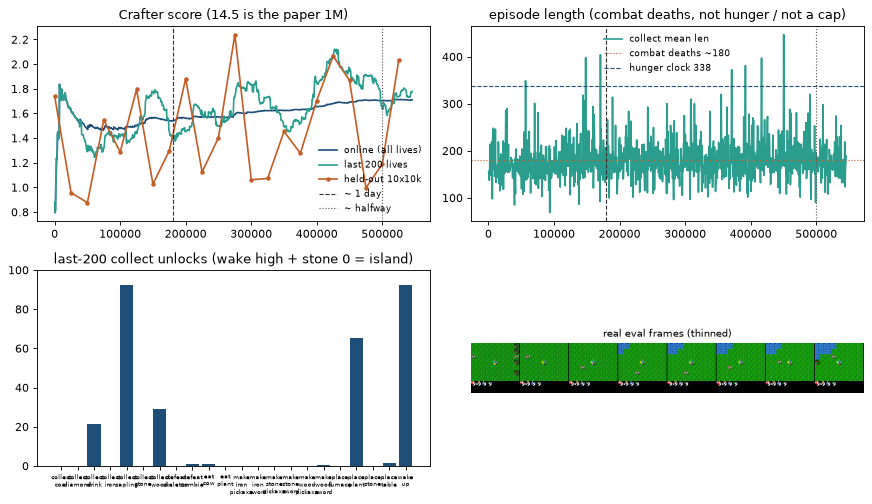

env 545536/1000000  heldout_score=2.031  online_score=1.710  last200=1.779  ac_H=0.431  ep_len=189  eval_len=200
done checkpoints\m16_xl_r512_acwarmup\ckpt_final.pt


KeyboardInterrupt: 

: 

In [ ]:
# Leftover M16 kernel still has the old collector in memory.
_old = str(ckpt_dir).replace("\\", "/") + " " + str(results_dir).replace("\\", "/")
if any(tag in _old for tag in ("m11", "m12_xl", "m13_xl", "m14_xl", "m15_xl", "m16_xl")):
    raise RuntimeError(
        f"this kernel is still on {ckpt_dir} / {results_dir}. "
        "Interrupt, restart the kernel, then run EVERY cell from the top. "
        "Do not re-run only this cell. Leave a live M16 kernel alone."
    )

# Hard re-bind. A leftover M16 kernel must die here.
CONFIG = Path("configs/m17_xl_paper.yaml")
cfg = load_yaml(CONFIG)
train = cfg["train"]
ckpt_dir = Path(train["checkpoint_dir"])
results_dir = Path(train["results_dir"])
log_dir = Path(train["log_dir"])
replay_out = Path(train["replay_out"])
for _p in (ckpt_dir, results_dir, log_dir, replay_out.parent):
    _p.mkdir(parents=True, exist_ok=True)
ONE_DAY_ENV = 180_000
HALF_ENV = 500_000
_wm_u, _ac_u = loop_updates(train)
if (
    CONFIG.name != "m17_xl_paper.yaml"
    or float(train.get("train_ratio") or 0) != 512
    or int(train["seq_len"]) != 64
    or int(train["batch_size"]) != 8
    or _wm_u != 16
    or _ac_u != 16
    or int(train.get("ac_warmup_env", 0) or 0) != 0
    or "m17_xl_paper" not in str(ckpt_dir).replace("\\", "/")
):
    raise RuntimeError(
        f"refusing {CONFIG.name} ratio={train.get('train_ratio')} "
        f"seq={train.get('seq_len')} batch={train.get('batch_size')} "
        f"wm/ac={_wm_u}/{_ac_u} ckpt={ckpt_dir}. Restart kernel, run ALL cells."
    )

writer = SummaryWriter(log_dir=str(log_dir))
history: list[dict] = []
eval_history: list[dict] = []
metrics_path = results_dir / "train_metrics.json"
eval_path = results_dir / "eval_metrics.json"
episodes_path = results_dir / "collect_episodes.jsonl"
collect_log = load_jsonl(episodes_path)
if env_steps > 0 and metrics_path.is_file():
    prev = json.loads(metrics_path.read_text(encoding="utf-8"))
    history = [h for h in prev if int(h.get("env_steps", 0)) <= env_steps]
if env_steps > 0 and eval_path.is_file():
    prev_e = json.loads(eval_path.read_text(encoding="utf-8"))
    eval_history = [h for h in prev_e if int(h.get("env_steps", 0)) <= env_steps]
if env_steps > 0:
    collect_log = [r for r in collect_log if int(r.get("env_steps", 0)) <= env_steps]
else:
    collect_log = []

target = int(train["env_steps"])
collect_every = int(train["collect_every"])
from training.outer_loop import loop_updates

wm_updates, ac_updates = loop_updates(train, env_steps=env_steps)
imag_gradient = str(train.get("imag_gradient", "both"))
eval_every = int(train["eval_every"])
log_every = int(train["log_every"])
dashboard_every = int(train.get("dashboard_every", 1000))
image_every = int(train["image_every"])
ckpt_every = int(train["checkpoint_every"])
replay_every = int(train.get("replay_every", ckpt_every))
start_mode = str(train.get("start_mode", "all"))
last_vis = None
last_eval_frames = None
last_percents: dict[str, float] = {}


def refresh_last200_percents() -> None:
    """Bar chart is last-200 collect, not the n=10 eval bag."""
    global last_percents
    if collect_log:
        last_percents = success_percents(collect_log[-200:])
    else:
        last_percents = {n: 0.0 for n in ACHIEVEMENT_NAMES}


refresh_last200_percents()

_ckpt = str(ckpt_dir).replace("\\", "/")
if "m17_xl_paper" not in _ckpt or any(
    tag in _ckpt
    for tag in (
        "m8_xl_acfix", "m7_xl", "m7_paper", "m9_xl", "m10_xl_r128",
        "m11_xl", "m12_xl", "m13_xl", "m14_xl", "m15_xl", "m16_xl",
    )
):
    raise RuntimeError(
        f"this kernel is still writing {ckpt_dir} at env_steps={env_steps}. "
        "Interrupt, restart the kernel, run from the top. M17 writes "
        "checkpoints/m17_xl_paper and must start at 0."
    )


def _thin_history(hist: list[dict], max_points: int = 800) -> list[dict]:
    if len(hist) <= max_points:
        return hist
    stride = max(1, len(hist) // max_points)
    return hist[::stride]


def _dashboard_strip(images: np.ndarray, keep_every: int = 2) -> np.ndarray:
    tiles = [images[i] for i in range(0, images.shape[0], keep_every)]
    return np.concatenate(tiles, axis=1)


def show_progress(hist, evals, vis_nchw, eval_frames, percents, steps_per_sec=None):
    status = ""
    if hist:
        h = hist[-1]
        rate = f"  ({steps_per_sec:.2f} env/s)" if steps_per_sec else ""
        ev = evals[-1].get("eval_crafter_score", float("nan")) if evals else float("nan")
        ep_len = float("nan")
        for p in reversed(hist):
            if "collect_ep_len" in p and np.isfinite(p.get("collect_ep_len", float("nan"))):
                ep_len = float(p["collect_ep_len"])
                break
        ev_len = evals[-1].get("eval_length", float("nan")) if evals else float("nan")
        status = (
            f"env {h['env_steps']}/{target}  heldout_score={ev:.3f}  "
            f"online_score={h.get('online_crafter_score', float('nan')):.3f}  "
            f"last200={h.get('online_crafter_score_last200', float('nan')):.3f}  "
            f"ac_H={h.get('ac_entropy', float('nan')):.3f}  "
            f"ep_len={ep_len:.0f}  eval_len={ev_len:.0f}{rate}"
        )
    try:
        clear_output(wait=False)
        plot_h = _thin_history(hist)
        fig = plt.figure(figsize=(11, 6.4), dpi=80)
        ax0 = fig.add_subplot(2, 2, 1)
        if plot_h:
            ax0.plot(
                [p["env_steps"] for p in plot_h],
                [p.get("online_crafter_score", float("nan")) for p in plot_h],
                color="#1f4e79",
                label="online (all lives)",
            )
            ax0.plot(
                [p["env_steps"] for p in plot_h],
                [p.get("online_crafter_score_last200", float("nan")) for p in plot_h],
                color="#2a9d8f",
                label="last 200 lives",
            )
        if evals:
            ax0.plot(
                [p["env_steps"] for p in evals],
                [p.get("eval_crafter_score", float("nan")) for p in evals],
                color="#c45c26",
                marker=".",
                label="held-out 10x10k",
            )
        ax0.axvline(ONE_DAY_ENV, color="#333", ls="--", lw=1, label="~ 1 day")
        ax0.axvline(HALF_ENV, color="#555", ls=":", lw=1, label="~ halfway")
        ax0.set_title("Crafter score (14.5 is the paper 1M)")
        ax0.legend(frameon=False, fontsize=8)
        ax1 = fig.add_subplot(2, 2, 2)
        if plot_h:
            xs = [p["env_steps"] for p in plot_h]
            last_len = float("nan")
            lens = []
            for p in plot_h:
                if "collect_ep_len" in p and np.isfinite(p.get("collect_ep_len", float("nan"))):
                    last_len = float(p["collect_ep_len"])
                lens.append(last_len)
            ax1.plot(xs, lens, color="#2a9d8f", label="collect mean len")
        ax1.axhline(180, color="#c45c26", ls=":", lw=1, label="combat deaths ~180")
        ax1.axhline(338, color="#1f4e79", ls="--", lw=1, label="hunger clock 338")
        ax1.axvline(ONE_DAY_ENV, color="#333", ls="--", lw=1)
        ax1.axvline(HALF_ENV, color="#555", ls=":", lw=1)
        ax1.set_title("episode length (combat deaths, not hunger / not a cap)")
        ax1.legend(frameon=False, fontsize=8)
        ax2 = fig.add_subplot(2, 2, 3)
        if percents:
            names = [n.replace("_", "\n") for n in ACHIEVEMENT_NAMES]
            vals = [percents.get(n, 0.0) for n in ACHIEVEMENT_NAMES]
            ax2.bar(range(len(names)), vals, color="#1f4e79")
            ax2.set_xticks(range(len(names)))
            ax2.set_xticklabels(names, fontsize=5)
        ax2.set_ylim(0, 100)
        ax2.set_title("last-200 collect unlocks (wake high + stone 0 = island)")
        ax3 = fig.add_subplot(2, 2, 4)
        shown = False
        if eval_frames is not None:
            ax3.imshow(_dashboard_strip(eval_frames[:16]))
            ax3.set_title("real eval frames (thinned)", fontsize=9)
            shown = True
        elif vis_nchw is not None:
            seq = vis_nchw[0].detach().float().clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()
            ax3.imshow(_dashboard_strip((seq * 255).astype(np.uint8)))
            ax3.set_title("imagined decode (not skill)", fontsize=9)
            shown = True
        if shown:
            ax3.axis("off")
        fig.tight_layout()
        display(fig)
    except Exception as exc:
        print(f"[dashboard skipped: {type(exc).__name__}: {exc}]", flush=True)
    finally:
        plt.close("all")
    if status:
        print(status, flush=True)


def run_eval(step: int):
    global last_eval_frames
    result = evaluate_policy(
        eval_env,
        world_model,
        actor,
        device=device,
        n_episodes=int(train["eval_episodes"]),
        max_steps=int(train.get("eval_max_steps", train["max_episode_steps"])),
        amp_dtype=amp_dtype,
        seed=int(train.get("eval_seed", 100_000)),
    )
    log_eval(result, step, eval_history, writer)
    last_eval_frames = result.frames
    if result.frames is not None:
        save_eval_gif(result.frames, results_dir / f"eval_step_{step:06d}.gif")
    eval_path.write_text(json.dumps(eval_history), encoding="utf-8")


print(
    f"{CONFIG.stem} to {target} env steps on {device} "
    f"(start={env_steps}, remaining={target - env_steps}, "
    f"wm/ac={wm_updates}/{ac_updates}, "
    f"ac_warmup_env={int(train.get('ac_warmup_env', 0) or 0)}, "
    f"imag_gradient={imag_gradient}, "
    f"slow_critic={slow_critic is not None})...",
    flush=True,
)
print("kill switch: ac_H under 0.15 at 30k means the fix did not take", flush=True)
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

last_log_time = time.time()
last_log_env = env_steps
pending_lens: list[float] = []
pending_rets: list[float] = []
last_ep_len = float("nan")
last_ep_ret = float("nan")
if env_steps == 0 or not eval_history:
    print("held-out 10x10k of the current (fresh) actor...", flush=True)
    t_eval = time.time()
    run_eval(env_steps)
    print(
        f"held-out eval done in {time.time() - t_eval:.0f}s (not counted in env/s)",
        flush=True,
    )
show_progress(history, eval_history, last_vis, last_eval_frames, last_percents)
last_log_time = time.time()
last_log_env = env_steps

try:
    while env_steps < target:
        wm_updates, ac_updates = loop_updates(train, env_steps=env_steps)
        cycle = outer_cycle(
            collector,
            world_model,
            actor,
            critic,
            wm_optim,
            ac_optim,
            buffer,
            device=device,
            wm_train_cfg=wm_train_cfg,
            collect_every=collect_every,
            wm_updates=wm_updates,
            ac_updates=ac_updates,
            batch_size=int(train["batch_size"]),
            seq_len=int(train["seq_len"]),
            retnorm=retnorm,
            horizon=int(train["horizon"]),
            start_mode=start_mode,
            lam=float(train.get("lam", 0.95)),
            discount=float(train.get("discount", 0.997)),
            entropy_scale=float(train.get("entropy_scale", 3.0e-4)),
            imag_gradient=imag_gradient,
            imag_gradient_mix=float(train.get("imag_gradient_mix", 0.0)),
            slow_critic=slow_critic,
            amp_dtype=amp_dtype,
            scaler=scaler,
            wm_max_grad_norm=float(train.get("wm_max_grad_norm", 1000.0)),
            ac_max_grad_norm=float(train.get("ac_max_grad_norm", 100.0)),
        )
        prev_steps = env_steps
        env_steps += collect_every
        if cycle.wm_metrics is not None:
            wm_steps += wm_updates
        if cycle.ac_metrics is not None:
            ac_steps += ac_updates

        row = {"env_steps": env_steps, "wm_steps": wm_steps, "ac_steps": ac_steps}
        if cycle.wm_metrics:
            row.update({f"wm_{k}": v for k, v in cycle.wm_metrics.items()})
        if cycle.ac_metrics:
            row.update({f"ac_{k}": v for k, v in cycle.ac_metrics.items()})
        row["collect_reward"] = float(cycle.collect["reward_mean"])
        row["collect_entropy"] = float(cycle.collect["entropy"])
        finished = cycle.collect.get("episodes") or []
        if finished:
            absorb_finished(finished, pending_lens, pending_rets)
            collect_log = record_finished_episodes(
                finished, env_steps, episodes_path, collect_log
            )
            refresh_last200_percents()

        sps = None
        do_log = (
            crossed_interval(prev_steps, env_steps, log_every)
            or env_steps >= target
        )
        do_dash = crossed_interval(prev_steps, env_steps, dashboard_every)
        if do_log:
            now = time.time()
            dt = max(now - last_log_time, 1e-6)
            sps = (env_steps - last_log_env) / dt
            last_log_time = now
            last_log_env = env_steps
            last_ep_len, last_ep_ret = flush_episode_window(
                pending_lens, pending_rets, last_ep_len, last_ep_ret
            )
            if np.isfinite(last_ep_len):
                row["collect_ep_len"] = last_ep_len
                row["collect_ep_return"] = last_ep_ret
            row["env_steps_per_sec"] = sps
            if collect_log:
                online_score, _ = score_from_episodes(collect_log, budget=target)
                row["online_crafter_score"] = online_score
                recent, _ = score_from_episodes(collect_log[-200:])
                row["online_crafter_score_last200"] = recent
            history.append(row)
            for k, v in row.items():
                if k != "env_steps" and isinstance(v, (int, float)) and np.isfinite(v):
                    writer.add_scalar(f"loop/{k}", float(v), env_steps)
            vram = vram_peak_gb()
            if vram:
                row["vram_alloc"] = vram[0]
            if not do_dash:
                ev = eval_history[-1].get("eval_crafter_score", float("nan")) if eval_history else float("nan")
                print(
                    f"env {env_steps}/{target}  heldout_score={ev:.3f}  "
                    f"online_score={row.get('online_crafter_score', float('nan')):.3f}  "
                    f"last200={row.get('online_crafter_score_last200', float('nan')):.3f}  "
                    f"ac_H={row.get('ac_entropy', float('nan')):.3f}  "
                    f"ep_len={row.get('collect_ep_len', float('nan')):.0f}  "
                    f"({sps:.2f} env/s)",
                    flush=True,
                )
        if do_dash:
            show_progress(
                history, eval_history, last_vis, last_eval_frames, last_percents, steps_per_sec=sps
            )

        if crossed_interval(prev_steps, env_steps, eval_every):
            run_eval(env_steps)
            show_progress(
                history, eval_history, last_vis, last_eval_frames, last_percents, steps_per_sec=sps
            )

        if cycle.rollout is not None and crossed_interval(
            prev_steps, env_steps, image_every
        ):
            last_vis = decode_imagination(world_model, cycle.rollout.feat, max_starts=1)
            save_imagination_strip(last_vis, results_dir / f"imagine_step_{env_steps:06d}.png")
            save_imagination_gif(last_vis, results_dir / f"imagine_step_{env_steps:06d}.gif")

        if crossed_interval(prev_steps, env_steps, ckpt_every):
            payload = joint_payload(
                env_steps=env_steps,
                wm_steps=wm_steps,
                ac_steps=ac_steps,
                world_model=world_model,
                wm_optim=wm_optim,
                actor=actor,
                critic=critic,
                ac_optim=ac_optim,
                retnorm=retnorm,
                collect_seed=collector.next_seed,
                slow_critic=slow_critic,
            )
            save_checkpoint(ckpt_dir / f"ckpt_step_{env_steps}.pt", payload)
            save_checkpoint(ckpt_dir / "ckpt_latest.pt", payload)
            metrics_path.write_text(json.dumps(history), encoding="utf-8")
            eval_path.write_text(json.dumps(eval_history), encoding="utf-8")
            print(f"wrote {ckpt_dir / f'ckpt_step_{env_steps}.pt'}", flush=True)
            gc.collect()

        if crossed_interval(prev_steps, env_steps, replay_every):
            save_replay(buffer, replay_out)
            print(f"wrote replay {replay_out}", flush=True)
finally:
    payload = joint_payload(
        env_steps=env_steps,
        wm_steps=wm_steps,
        ac_steps=ac_steps,
        world_model=world_model,
        wm_optim=wm_optim,
        actor=actor,
        critic=critic,
        ac_optim=ac_optim,
        retnorm=retnorm,
        collect_seed=collector.next_seed,
        slow_critic=slow_critic,
    )
    save_checkpoint(ckpt_dir / "ckpt_final.pt", payload)
    save_checkpoint(ckpt_dir / "ckpt_latest.pt", payload)
    save_replay(buffer, replay_out)
    metrics_path.write_text(json.dumps(history), encoding="utf-8")
    eval_path.write_text(json.dumps(eval_history), encoding="utf-8")
    writer.flush()
    writer.close()
    collect_env.close()
    eval_env.close()
    show_progress(history, eval_history, last_vis, last_eval_frames, last_percents)
    print("done", ckpt_dir / "ckpt_final.pt")


## Stop / continue

- Watch **last-200 collect stone / table / pickaxe**, not the 1.7 gmean line.
- Actor is on from step 0. No 25k warmup unlock.
- **100k:** `recon_l1` should be ~0.004. That is the WM look.
- **~180k / 500k:** success = stone leaves 0. Fail = same wood-hold as M16.
- `ac_H` > 0.15. Kill if it sits near 0.10.
- First print must show `seq=64 batch=8`. If you see `seq=32`, this is still M16.
- Do not load `checkpoints/m16_xl_r512_acwarmup` or any earlier XL dir.
- Interrupt after `wrote ckpt_step_...` (or the finally flush). `RESUME="auto"` only on this M17 dir.


In [ ]:
assert len(history) >= 1 or env_steps >= target, "need at least one logged cycle or a finished target"
checks: list[tuple[str, bool, str]] = []

def _finite_keys(rows, keys):
    for row in rows:
        for k in keys:
            if k in row and isinstance(row[k], (int, float)) and not np.isfinite(row[k]):
                return False, k, row.get("env_steps")
    return True, "", None

ok_h, bad_k, bad_s = _finite_keys(history, ["wm_total", "ac_total", "ac_entropy", "online_crafter_score"])
checks.append(("logged metrics are finite", ok_h, f"NaN in {bad_k} at env_steps={bad_s}"))
last = history[-1] if history else {"ac_entropy": float("nan"), "env_steps": env_steps}
ent = float(last.get("ac_entropy", last.get("collect_entropy", 0.0)))
checks.append(
    (f"policy entropy is alive (last={ent:.3f} > 0.1)", ent > 0.1 or not history, "actor collapsed")
)
checks.append(
    (
        f"collect jsonl n={len(collect_log)}",
        episodes_path.is_file() or len(collect_log) >= 0,
        "missing collect_episodes.jsonl",
    )
)
checks.append(
    (
        f"eval logs n={len(eval_history)} (>=1 held-out)",
        len(eval_history) >= 1,
        "need the 100k held-out 10x10k snapshot",
    )
)
if eval_history:
    last_sc = float(eval_history[-1].get("eval_crafter_score", float("nan")))
    checks.append(
        (f"last held-out gmean is finite ({last_sc:.3f})", np.isfinite(last_sc), "score NaN")
    )

reload_ok = False
ckpt_latest = ckpt_dir / "ckpt_latest.pt"
if ckpt_latest.is_file():
    payload = torch.load(ckpt_latest, weights_only=False, map_location="cpu")
    need = ["env_steps", "world_model", "actor", "critic", "wm_optim", "ac_optim", "retnorm"]
    reload_ok = all(k in payload for k in need)
checks.append(("ckpt_latest has joint payload", reload_ok, "missing keys in ckpt_latest.pt"))

print(f"env steps trained: {env_steps}")
failed = False
for name, ok, msg in checks:
    mark = "PASS" if ok else "FAIL"
    print(f"[{mark}] {name}" + ("" if ok else f" — {msg}"))
    failed = failed or not ok
if eval_history:
    print(
        f"held-out gmean {eval_history[0].get('eval_crafter_score', float('nan')):.3f} → "
        f"{eval_history[-1].get('eval_crafter_score', float('nan')):.3f}  "
        "(caption: M17 Table B.1 knobs on 16 GiB; not 14.5 unless this is a finished 1M)"
    )
print("RESULT:", "FAIL" if failed else "PASS — M17 paper-recipe run logged")
if "m17_xl_paper" not in str(ckpt_dir).replace("\\", "/"):
    raise RuntimeError(f"checks ran against {ckpt_dir}, not checkpoints/m17_xl_paper")
gif = results_dir / f"eval_step_{env_steps:06d}.gif"
if gif.is_file():
    print("GIF:", gif)